# Conectando con el Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importando librerias necesarias

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# Función para el calculo del error de los parmetros y $\chi^2$ (https://es.wikipedia.org/wiki/Prueba_%CF%87%C2%B2_de_Pearson)

In [3]:
def print_resultados (xdata, ydata, yerr, errf, pfinal, covar,nparm=1):

    # Grados de Libertad
    degfree = len(xdata)  - nparm

    # Chi Cuadrado reducido
    s_sq = (errf(pfinal,xdata, ydata, yerr)**2).sum()/degfree
    print ("Chi^2_reducido: {:.2f}".format(s_sq))

    pcov = covar * s_sq
    perr = np.sqrt(np.diag(covar))

    # Valor de los Parametros Ajustados
    for i in np.arange(nparm):
        print ("P_{} = {:.2f} +- {:.2f} ".format(i, pfinal[i], perr[i]))

# Cargando los datos del Laboratorio
* Recordar que los numeros deben cambiar la coma por punto.
* La lineas iniciales (por, ej. t x y) deben ir comentadas con "#" 

In [4]:
# Colocar la ruta del google drive del archivo de los tados
#data=np.loadtxt('/content/drive/MyDrive/Movimiento parabolico/lanzamiento_medio.txt')
data=np.loadtxt('medio.txt')
print(data)

[[0.000e+00 0.000e+00 0.000e+00]
 [3.300e-02 1.060e-01 9.964e-02]
 [6.700e-02 2.120e-01 1.920e-01]
 [1.000e-01 3.170e-01 2.700e-01]
 [1.330e-01 4.220e-01 3.270e-01]
 [1.670e-01 5.260e-01 3.800e-01]
 [2.000e-01 6.300e-01 4.150e-01]
 [2.330e-01 7.360e-01 4.330e-01]
 [2.670e-01 8.400e-01 4.430e-01]
 [3.000e-01 9.480e-01 4.340e-01]
 [3.330e-01 1.052e+00 4.150e-01]
 [3.670e-01 1.158e+00 3.830e-01]
 [4.000e-01 1.263e+00 3.340e-01]
 [4.330e-01 1.368e+00 2.760e-01]
 [4.670e-01 1.475e+00 1.990e-01]
 [5.000e-01 1.583e+00 1.120e-01]
 [5.330e-01 1.693e+00 8.493e-04]]


# Normalizando para que las variables timpo (t), coordenada X (x) y coordenada Y (y) inicialicen en 0, 0, 0

* si el x o y estan negativos, multiplicar por -1, por ejemplo:
  
> x=(data[:,1]-data[0,1])*-1

* Si x aumenta de derecha-izquierda en vez de izquierda-derecha(normal)

> x=(data[:,1]-data[0,1])[::-1]


In [5]:
t=data[:,0]-data[0,0]
x=data[:,1]-data[0,1]
y=data[:,2]-data[0,2]

# Graficando "x vs t", "y vs t", "x vs y"

Altura máxima alcanzada: 0.44 m
El alcance máximo: 1.69 m


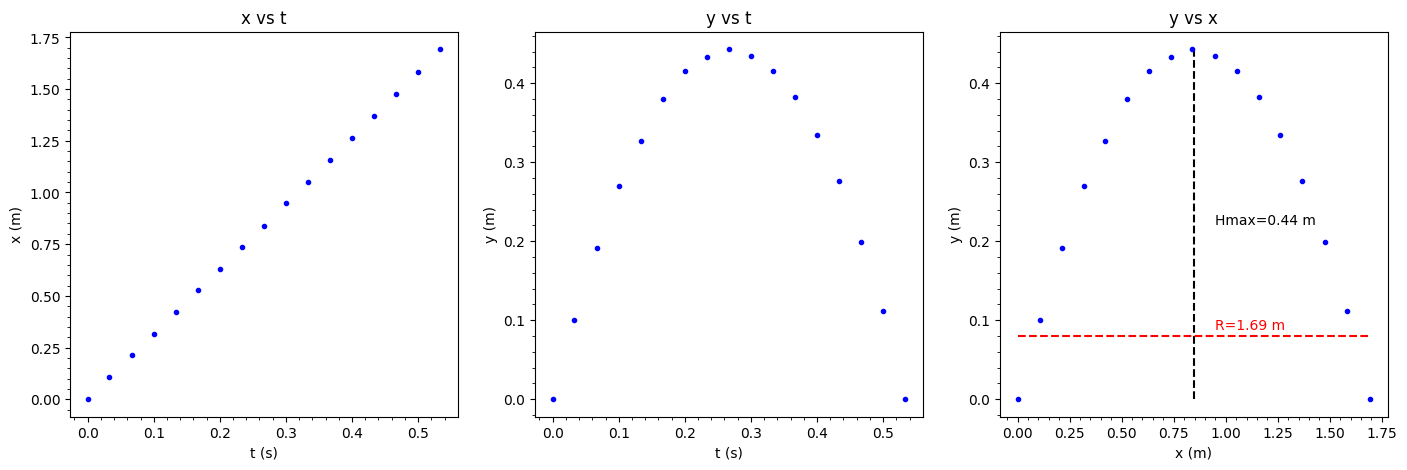

In [25]:
plt.figure(figsize=(17,5))


# Graficando x vs t
plt.subplot(1,3,1)
plt.plot(t,x, 'b.')
plt.ylabel ('x (m)')
plt.xlabel('t (s)')
plt.title('x vs t')
plt.minorticks_on()


# Graficando y vs t
plt.subplot(1,3,2)
plt.plot(t,y, 'b.')
plt.ylabel ('y (m)')
plt.xlabel('t (s)')
plt.title('y vs t')
plt.minorticks_on()


# Graficando x vs y
plt.subplot(1,3,3)

ymax_pos = np.argmax(y)
ymax= y[ymax_pos]
print("Altura máxima alcanzada: {:.2f} m".format(ymax))
xmax_pos = np.argmax(x)
xmax= x[xmax_pos]
print("El alcance máximo: {:.2f} m".format(xmax))

plt.vlines(xmax*0.5,0,ymax,ls='dashed',color='k')
plt.text(xmax*0.5+0.1,ymax*0.5, 'Hmax={:.2f} m'.format(ymax))

plt.hlines(ymax*0.18,0,xmax,ls='dashed',color='r')
plt.text(xmax*0.5+0.1,ymax*0.2, 'R={:.2f} m'.format(xmax), color='r')

plt.plot(x,y, 'b.')
plt.ylabel ('y (m)')
plt.xlabel('x (m)')
plt.title('y vs x')
plt.minorticks_on()

# Ajustanto la curva "x vs t"

## Definiendo la Función de ajuste 

$x=V_{0x}t$


Ademas se define un función error ($\xi$) que será la que el programa 
ajuste minimize:

$\xi=\sum_{i=0}^{i=n} \frac{dato_i - model_i}{error_i}$

Para esa función se necesita un vector error, en general tomamos 1 cm, eso depende
de la resolucióon de la imagen.

In [33]:
def ajusteX(vox,t):
  x = vox * t
  return x


def error (vox,t,x,x_err):
  return((x-ajusteX(vox, t))/x_err)

x_err = 0.01+np.zeros((len(x)))

## Creando un array (vector) para testar un parametro de entrada para $V_{0x}$

En este ejemplo, damos para vox=4

In [31]:
t_test=np.linspace(0,t[:-1],100)
x_test=ajusteX(4,t_test)

## Graficando la función ajuste con los datos para ver que tan cerca está nuestro valor inicial de los datos

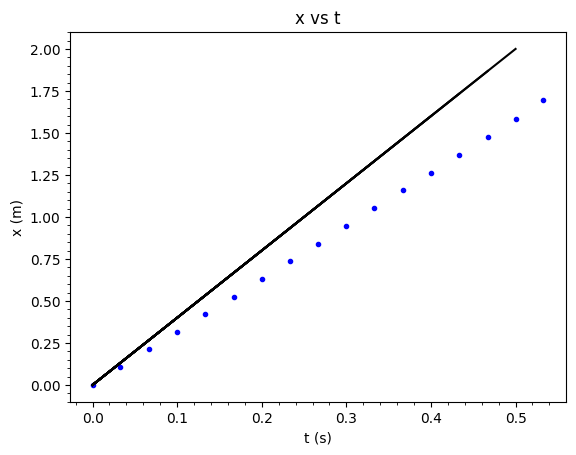

In [32]:
plt.plot(t,x, 'b.')
plt.plot(t_test,x_test, 'k')
plt.ylabel ('x (m)')
plt.xlabel('t (s)')
plt.title('x vs t')
plt.minorticks_on()

## Usando el metodos de Optimización Minimos Cuadrados (https://es.wikipedia.org/wiki/M%C3%ADnimos_cuadrados) para encontrar el parametro que ajusta mejor los datos

In [35]:
resultado=optimize.leastsq(error,[4], args=(t,x,x_err), full_output=1 )
print("Mejor ajuste para la Vox: {:.2f} m/s".format(resultado[0][0]))

Mejor ajuste para la Vox: 3.16 m/s


## Calculado el $\chi^2$ y el error del parametro de ajuste

In [36]:
print_resultados (t,x, x_err, error, resultado[0], resultado[1],nparm=1)

Chi^2_reducido: 0.07
P_0 = 3.16 +- 0.01 


## Graficando el ajuste con los datos observados

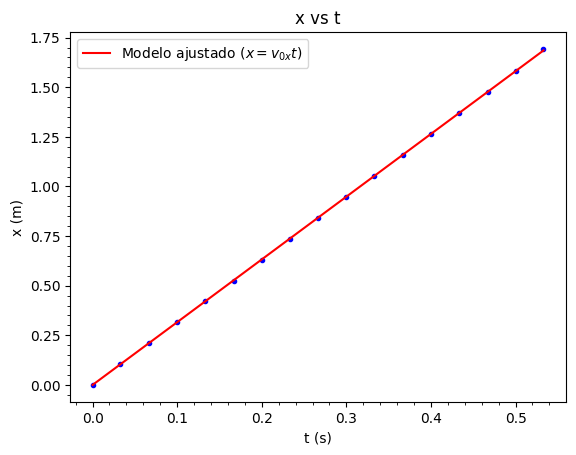

In [37]:
x_test = ajusteX(resultado[0][0],t)

plt.plot(t,x, 'b.')
plt.plot(t, x_test, 'r-', label='Modelo ajustado ($x=v_{0x}t$)')
plt.ylabel ('x (m)')
plt.xlabel('t (s)')
plt.title('x vs t')
plt.minorticks_on()
plt.legend()


# Ajustanto la curva "y vs t" - g fijo

## Definiendo la Función de ajuste 

$y=V_{0y}t-\frac{1}{2}gt^2$

Ademas se define un función error ($\xi$) que será la que el programa 
ajuste minimize:

$\xi=\sum_{i=0}^{i=n} \frac{dato_i - model_i}{error_i}$

Para esa función se necesita un vector error, en general tomamos 1 cm, eso depende
de la resolucióon de la imagen.

In [38]:
def ajusteY(voy,t):
  y = voy * t-((9.81)/2)*t**2
  return y

def errory (voy,t,y,y_err):
  return((y-ajusteY(voy,t))/y_err)

y_err = 0.01+np.zeros((len(x)))


## Creando un array para testar un parametro de entrada para $V_{0y}$

En este ejemplo, damos para voy=3

In [40]:
t_test=np.linspace(0,t[-1],100)
y_test=ajusteY(3,t_test)

## Graficando la función ajuste con los datos para ver que tan cerca está nuestro valor inicial de los datos

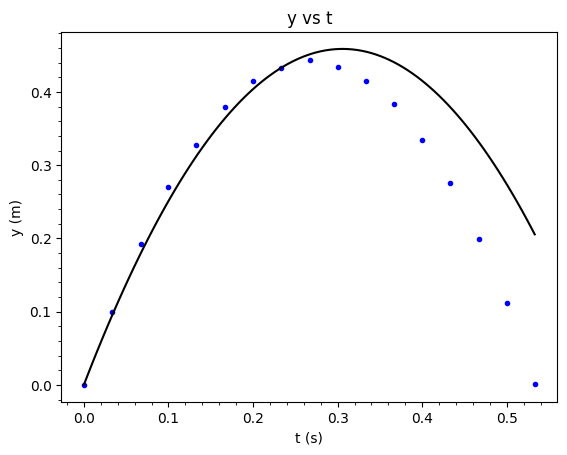

In [41]:
plt.plot(t,y, 'b.')
plt.plot(t_test,y_test, 'k')
plt.ylabel ('y (m)')
plt.xlabel('t (s)')
plt.title('y vs t')
plt.minorticks_on()

## Usando el metodos de Optimización Minimos Cuadrados

In [42]:
resultado=optimize.leastsq(errory,[3], args=(t,y,y_err), full_output=1 )
print("Mejor ajuste para la Voy: {:.2f} m/s".format(resultado[0][0]))

Mejor ajuste para la Voy: 2.78 m/s


In [43]:
print_resultados (t,y, y_err, errory, resultado[0], resultado[1],nparm=1)

Chi^2_reducido: 18.90
P_0 = 2.78 +- 0.01 


## Graficando el ajuste con los datos observados

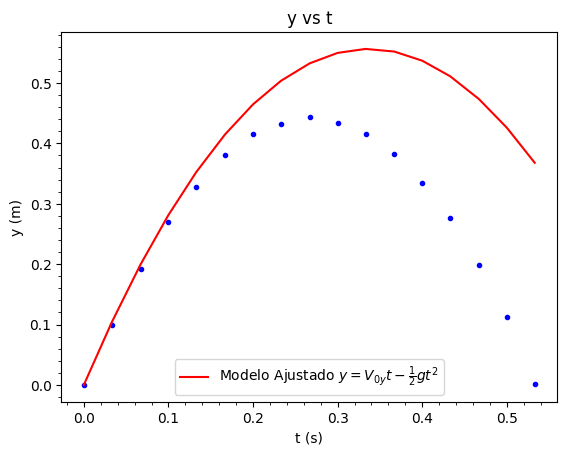

In [52]:
y_test = ajusteY(resultado[0][0],t)

plt.plot(t,y, 'b.')
plt.plot(t, y_test, 'r-', label='Modelo Ajustado $y=V_{0y}t-\\frac{1}{2}gt^2$')
plt.ylabel ('y (m)')
plt.xlabel('t (s)')
plt.title('y vs t')
plt.minorticks_on()
plt.legend()

# En caso que el la función no ajuste bien los datos

* Repetimos el ajuste dejando la gravedad (g) variable

## Definiendo una nueva función de ajuste, ahora dejando  "g" variable

In [46]:
def ajusteyg(pary,t):
  y = pary[0] * t-((pary[1])/2)*t**2
  return y

def erroryg (pary,t,y,y_err):
  return((y-ajusteyg(pary,t))/y_err)

## Usando el metodos de Optimización Minimos Cuadrados 

In [48]:
resultado=optimize.leastsq(erroryg,[3,9.81], args=(t,y,y_err), full_output=1 )
print("Mejor ajuste para la Voy {:.2f} m/s".format(resultado[0][0]))
print("Mejor ajuste para la g: {:.2f} m/s$^2$".format(resultado[0][1]))

Mejor ajuste para la Voy 3.30 m/s
Mejor ajuste para la g: 12.35 m/s$^2$


## Calculado el $\chi^2$ y el error de los parametros de ajuste

In [49]:
print_resultados (t,y, y_err, erroryg, resultado[0], resultado[1],nparm=2)

Chi^2_reducido: 0.07
P_0 = 3.30 +- 0.03 
P_1 = 12.35 +- 0.15 


## Graficando el ajuste con los datos observados

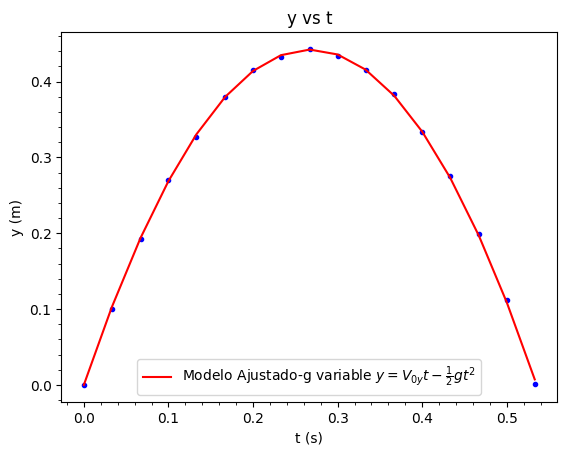

In [54]:
y_test = ajusteyg(resultado[0],t)

plt.plot(t,y, 'b.')
plt.plot(t, y_test, 'r-', label='Modelo Ajustado-g variable $y=V_{0y}t-\\frac{1}{2}gt^2$')
plt.ylabel ('y (m)')
plt.xlabel('t (s)')
plt.title('y vs t')
plt.minorticks_on()
plt.legend()

# Calculando el ángulo de Lanzamiento

In [64]:
Vox_ajustado = 3.16
Voy_ajustado = 3.30

ang_lanzamiento = np.rad2deg(np.arctan(Voy_ajustado/Vox_ajustado))

print ("Ángulo de lanzamiento: {:.1f}".format(ang_lanzamiento))

Ángulo de lanzamiento: 46.2
